# Машинное обучение, ФКН ВШЭ

## Практическое домашнее задание 3.1 Базовая генерация признаков

### Общая информация

Дата выдачи: 23.02.2026

Мягкий дедлайн: 12.03.2026 23:59MSK

Жесткий дедлайн: 16.03.2026 23:59MSK

### О задании

В данном задании вы познакомитесь с базовыми подходами для создания новых признаков в табличном машинном обучении. Вам понадобится подумать над тем, зачем мы делаем те или иные преобразования, научиться принимать решения, дающие наилучшие результаты, и узнать, как реализовывать их при помощи библиотек

### Оценивание и штрафы

Каждая из задач имеет определенную «стоимость» (указана в скобках около задачи). Максимально допустимая оценка за эту часть — 6 баллов. Детальнее про оценивание — в самом конце ноутбука.

Сдавать задание после указанного срока сдачи нельзя. При выставлении неполного балла за задание в связи с наличием ошибок на усмотрение проверяющего предусмотрена возможность исправить работу на указанных в ответном письме условиях.

Задание выполняется самостоятельно. «Похожие» решения считаются плагиатом и все задействованные студенты (в том числе те, у кого списали) не могут получить за него больше 0 баллов (подробнее о плагиате см. на странице курса). Если вы нашли решение какого-то из заданий (или его часть) в открытом источнике, необходимо указать ссылку на этот источник в отдельном блоке в конце вашей работы (скорее всего вы будете не единственным, кто это нашел, поэтому чтобы исключить подозрение в плагиате, необходима ссылка на источник).

Неэффективная реализация кода может негативно отразиться на оценке. Также оценка может быть снижена за плохо читаемый код и плохо считываемые диаграммы.

Все ответы должны сопровождаться кодом или комментариями о том, как они были получены.

### Формат сдачи
Задания сдаются через систему Anytask. Инвайт можно найти на странице курса. Присылать необходимо ноутбук с выполненным заданием. Сам ноутбук называйте в формате **homework-practice-03-base-Username.ipynb**, где Username — ваша фамилия.

### **Сетап**

<img style="float: right; padding-right:15px; padding-bottom:10px" src="https://i.postimg.cc/26KqqSb2/pomoika2.png" height=300px width=200px alt="Pomoika 2">
    
В этом домашнем задании мы будем работать с задачей классификации, но сконцентрируемся на том, что приносит не меньшую пользу, чем сами модели — замешиванию данных.

Целевая метрика уже выбрана за нас: мы будем считать $\text{ROC-AUC}$, но не простой, а коэффициент Джини:

$$ \text{Gini} = 2 \cdot \text{ROC-AUC} - 1$$

Конечная цель данного мероприятия — собрать пайплайн машинного обучения от и до, начиная с предобработки данных, заканчивая оптимизацией. При желании это можно доделать до целого пет-проекта, особенно если добавить сбор данных и деплой модели, но в дз этого не будет :(.

Цель конкретно базового ноутбука — познакомить вас с основными преобразованиями и собрать солидный фундамент для преобразований посложнее. 

In [1]:
from sklearn.metrics import roc_auc_score


def gini(y_true, y_score):
    return 2 * roc_auc_score(y_true, y_score) - 1.0

#### **Данные**

У вас на руках (на Kaggle) датасет по широко известной в неузких кругах видеоигре Dota 2, скачанный через OpenDota API и заботливо анонимизированный. Если вы не знакомы с игрой — ничего страшного, все необходимое для заданий в базовой части мы подробно опишем.

Нас интересует исход матча — победа или поражение, исходя из совершенно разных факторов (например, чтобы делать ставки на спорт, осуждаем?). Это информация о сессии, игроках, героях, и т д. **в первые 15 минут** после начала матча.

Краткая сводка об игре:

- Dota 2 — командная игра: 5 игроков за Свет (Radiant) против 5 за Тьму (Dire).
- Каждый игрок управляет уникальным героем со своим набором атрибутов и способностей.
- Цель — снести главную постройку на вражеской базе (в простонародье трон).
- В процессе матча игроки добывают золото и опыт, покупают предметы и убивают противников, чтобы стать сильнее.
- Ничьих не бывает, фиксированного таймера нет — матч длится до падения трона.

ПРОЧИТАТЬ:
сем по ROC-AUC и лекция про это же + AUC-PR - 1 вопрос

#### 📌 **Важнейшее замечание**

Предполагается, что у вас уже сложилось понимание:
- как крутить и вертеть данные, чтобы фиты делались твёрдо, трансформы ложились чётко, шейпы датафреймов стакались и нужные джойны джойнились;
- как рисовать читаемые графики;
- как проверять качество модели;

Пожалуйста, следите за этим очень-очень внимательно, иначе рискуете получить штраф и всеобщее порицание в нашем уютном МО-1 чатике (хотя, у этого есть плюсы).

Если возникнут вопросы по игровой части — **не стесняйтесь** спрашивать, гуглить, обращаться к GPT или, прости Господи, дотерам. Знание области — важнейшая составляющая хорошего фича инжиниринга

<div style="border-left: 5px solid #7298ce; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

Для лучшего понимания, в голубеньких пунктах будет небольшое <font color="#7298ce">**обоснование**</font> того, зачем вообще делается то или иное преобразование (в колабе придётся включать интуицию, там не работает HTML). Вы можете её скипнуть, если всё понятно и без этого

</div>

<div style="border-left: 5px solid #f68c9d; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(255, 116, 140, 0.05);">

В пунктах с розоватой, как у всеми любимого Pudge, расцветкой мы попросим вас написать <font color="#f68c9d">**Ответ**</font> на <font color="#f68c9d">**Вопрос**</font> или <font color="#f68c9d">**рефлексию**</font>, которая должна направить вашу мысль о том, как варить фичи, в нужном направлении. Уметь аргументировать свою точку зрения важно не менее

Пожалуйста, даже если вы уже прожжённый дед инсайд и дата-сайентист 14 уо, всё равно <font color="#f68c9d">**порефлексируйте**</font>. Количество потерянных нервных клеток и ваш успех на соревновании напрямую зависят от базовой предобработки.
Вы **можете** писать <font color="#f68c9d">**её**</font> ёмко, но только если **знаете** ответ

</div>

<div style="border-left: 5px solid #d18753; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(200, 156, 105, 0.05);">

<font>По ходу домашки вам придётся делать <font color="#d18753">**выборы**</font> и подбирать <font color="#d18753">**гиперпараметры**</font>. Какие-то из них важнее остальных. У ряда выборов последствия чисто номинальные, какие-то видоизменят другие задания, третьи полностью определят, как вы будете делать остальную домашку. 

Принимайте решения мудро. Не привязывайтесь к ним слишком сильно, возможно, в процессе вам захочется пересмотреть ваши жизненные приоритеты. Пробуйте, экспериментируйте, фичи это самое творческое, что есть в машинном обучении

При желании, в конце обоих ноутбуков есть инструменты, которые, при остром желании и избытке свободного времени, могут тупо перебрать все выборы и найти самый оптимальный, но это опционально
</div>

### **Часть 1. Это, так сказать, база. (3.25 балла)**

В которой студент учится смотреть на фичи под правильным углом и готовить из сырых данных простые, но аппетитные факторы

#### **Задание 1.1. Датасет** (0.5 балла)

Чтобы начать работу с данными, эти данные сперва нужно [загрузить](https://www.kaggle.com/t/6fd940fbeb1746a78031e5d0277f6105). Пока что нам потребуются лишь:

1. Информация о матчах - `matches_df_train.csv`.
2. Тестовые данные для соревнования - `matches_df_test.csv`.

Посмотрите на все csv-файлы выше, создайте под каждый из них отдельный датафрейм и отметьте (текстом или кодом):
- объемы таблиц: как в Мб, так и `df.shape`
- какие в них есть колонки по своему содержанию

In [2]:
# (´-`）.｡oO( ... YOUR CODE HERE ... )
import pandas as pd

df_train = pd.read_csv("matches_df_train.csv")
df_test = pd.read_csv("matches_df_test.csv")
print(f"Объем таблицы df_train строк {df_train.shape[0]}, колонок {df_train.shape[1]}, Мб {df_train.memory_usage(deep=True).sum() / (1024 * 1024)}")
print(f"Объем таблицы df_test строк {df_test.shape[0]}, колонок {df_test.shape[1]}, Мб {df_test.memory_usage(deep=True).sum() / (1024 * 1024)}\n")

print(f"Колонки для df_train:\n{df_train.dtypes}\n")
print(f"Колонки для df_test:\n{df_test.dtypes}\n")

Объем таблицы df_train строк 641090, колонок 7, Мб 92.50748825073242
Объем таблицы df_test строк 59748, колонок 5, Мб 8.0858793258667

Колонки для df_train:
match_id         int64
date            object
region          object
game_mode        int64
duration         int64
radiant_win       bool
avg_mmr        float64
dtype: object

Колонки для df_test:
match_id       int64
date          object
region        object
game_mode      int64
avg_mmr      float64
dtype: object



Отдельно хочется посмотреть распределение целевой переменной, покажите его, пожалуйста

radiant_win
True     0.510772
False    0.489228
Name: proportion, dtype: float64
radiant_win
True     327451
False    313639
Name: count, dtype: int64


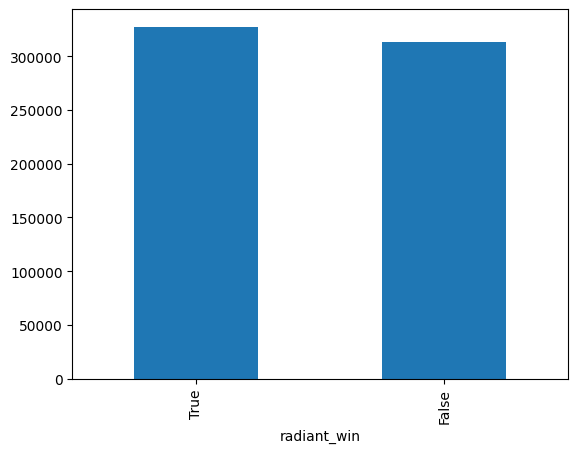

In [3]:
# (´-`）.｡oO( ... YOUR CODE HERE ... )
df_train["radiant_win"].value_counts().plot(kind="bar")
print(f"{df_train["radiant_win"].value_counts(normalize=True)}\n{df_train["radiant_win"].value_counts()}")


<div style="border-left: 5px solid #c27985; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(255, 116, 140, 0.05);">

**Вопрос:** подходящая ли в данном случае метрика $\text{Gini}$ в сравнении, например, с $\text{AUC-PR}$?

**Ответ:**
Gini дает преимущество относительно ROC-AUC отноительно случайной модели, ROC-AUC показывает качество лучше тогда, когда таргет примерно равен, а AUC-PR более точен в отражении неравенства между категориями таргета
</div>

#### **Задание 1.2. Категории** (0.75 балла)

Чтобы построить реально балдёжную модель, зачастую не получится просто написать фит предикт. О нет, это долгая и утомительная возня. А если нужно ещё и отчётики писать, то хоть <span style="color:grey"><font size="1">~~вешайся (осуждаем)~~ </font></span> увольняйся. Так и здесь. И того, что есть, уже хватит, чтобы продемонстрировать глубокую и тёмную сторону Dota Science.

В целом, данные уже содержат признаки, по которым что-то даже можно построить, в частности — регионы.

<div style="border-left: 5px solid #7298ce; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

У Radiant, по сравнению с Dire, исторически есть небольшое преимущество — чуть удобнее карта, порядок выбора героев и всё такое. В разных регионах бывают разные предпочтения по стилям игры и тактикам, и где-то это преимущество реализуют лучше

</div>

Посмотрите, где у нас содержится информация о регионе, на серверах которого был проведён матч, и постройте 2 графика:
1) Распределение регионов (процентное и абсолютное) на тренировочных и тестовых данных
2) Среднее значение таргета на трейне, в зависимости от региона

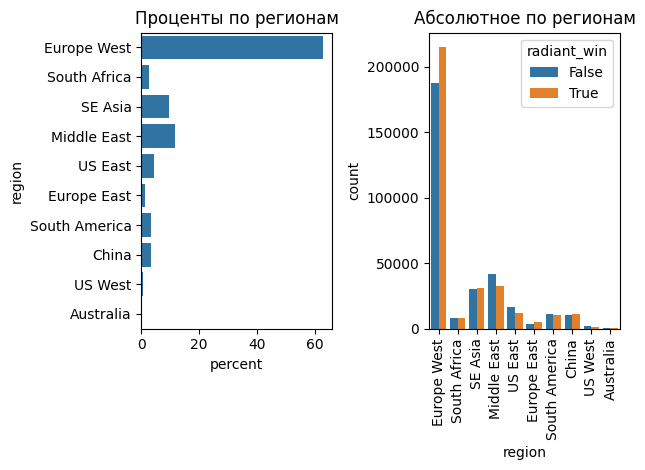

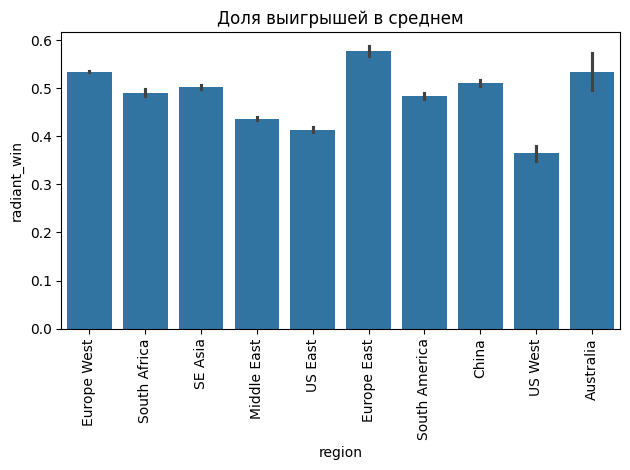

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
# (´-`）.｡oO( ... YOUR CODE HERE ... )
plt.figure()
plt.subplot(1, 2, 1)
plt.title("Проценты по регионам")
sns.countplot(df_train["region"], stat='percent')

plt.subplot(1, 2, 2)
plt.title("Абсолютное по регионам")
sns.countplot(data=df_train, x="region", hue="radiant_win")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

plt.figure()
sns.barplot(data=df_train, x="region", y="radiant_win")
plt.title("Доля выигрышей в среднем")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


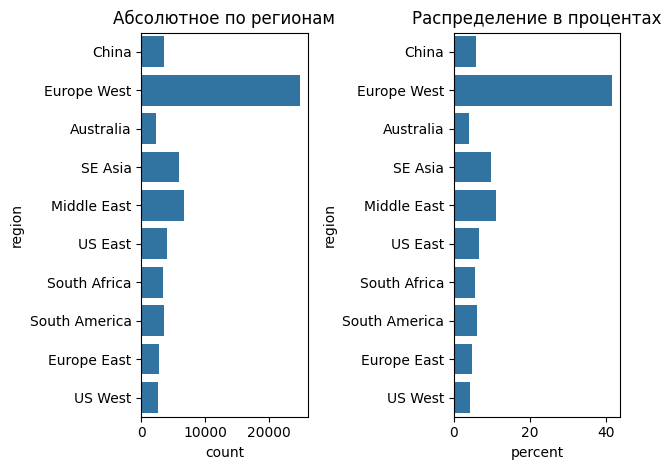

In [5]:
# (´-`）.｡oO( ... YOUR CODE HERE ... )
plt.figure()
plt.subplot(1, 2, 1)
plt.title("Абсолютное по регионам")
sns.countplot(df_test["region"])

plt.subplot(1, 2, 2)
plt.title("Распределение в процентах")
sns.countplot(df_test['region'], stat='percent')
plt.tight_layout()
plt.show()

<div style="border-left: 5px solid #c27985; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(255, 116, 140, 0.05);">

**Вопрос:** что вы можете сказать о распределении регионов? Объясните, получится ли вообще обучить по нему модель, есть ли там сигнал?

**Ответ:** 
В целом можно сказать, что Европа и Австралия имеют больший процент выигрыша radiant, при этом в топе низа рейтинга - Северная и центральная Америка. Влияние на выигрыш иногда сильное (около 10%-15%), закономерность прослеживается. Например, radiant-ы из восточной европы в 56% случаев выиграют, когда как radiant-ы из западной америки - в 35%. 
</div>

Наша первая развилка — <font color="#d18753">**выбор**</font>, какой из энкодеров стащить. Рекомендуется брать что-то из `category_encoders`, они похожи на стандартные из `sklearn`, но их больше и применять их проще.

| <font color="#d18753">**One-Hot Encoder**</font> | <font color="#d18753">**Target Encoder**</font> |
| :--- | :--- |
| Превращает категориальный признак в вектор из 0 и 1.  <br> 1 стоит на месте i‑го индекса, если у объекта есть i‑е значение признака. | Кодирует категориальный признак средним значением таргета.  <br> Среднее считается по всем объектам с i‑м значением признака. |

Можно взять и другой, но морально готовьтесь получить $\text{Gini} = 0$
</div>

<div style="border-left: 5px solid #7298ce; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">
Без энкодинга использовать категориальные признаки в линейных моделях, увы, нельзя, выбор без выбора 
</div>

In [6]:
!pip3 install -qU category-encoders


[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip


<div style="border-left: 5px solid #c27985; padding: 10px 20px 2px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(255, 116, 140, 0.05);">

**Вопрос:** какой из энкодеров кажется вам наиболее привлекательным? Почему?

**Ответ:**
Мне кажется более подходящим one-hot за счет того, что различных значений region немного - 9, что позволит избежать переобучения (если бы значений было бы больше), для target-encoder такое количество значений наоборот мало
</div>

Закодируйте колонку `region` выбранным вами способом

In [7]:
# (´-`）.｡oO( ... YOUR CODE HERE ... )
from category_encoders import OneHotEncoder

encoder = OneHotEncoder(cols=['region'],
                        use_cat_names=True)
encoded_array = encoder.fit_transform(df_train[['region']])
df_encoded = pd.DataFrame(encoded_array, columns=encoder.get_feature_names_out(['region']))

#### **Задание 1.3. Даты** (1.25 балла)

Если нам хочется видеть будущее, именно время диктует, что брать можно, а что никак нельзя

Найдите колонку дат на тренировочных данных и:
1. Постройте график доли побед Radiant в зависимости от даты матча
2. Сравните временные диапазоны на трейне и тесте

Временные диапазоны на train с 2024-01-01 до 2024-11-30
Временные диапазоны на test с 2024-12-01 до 2024-12-31


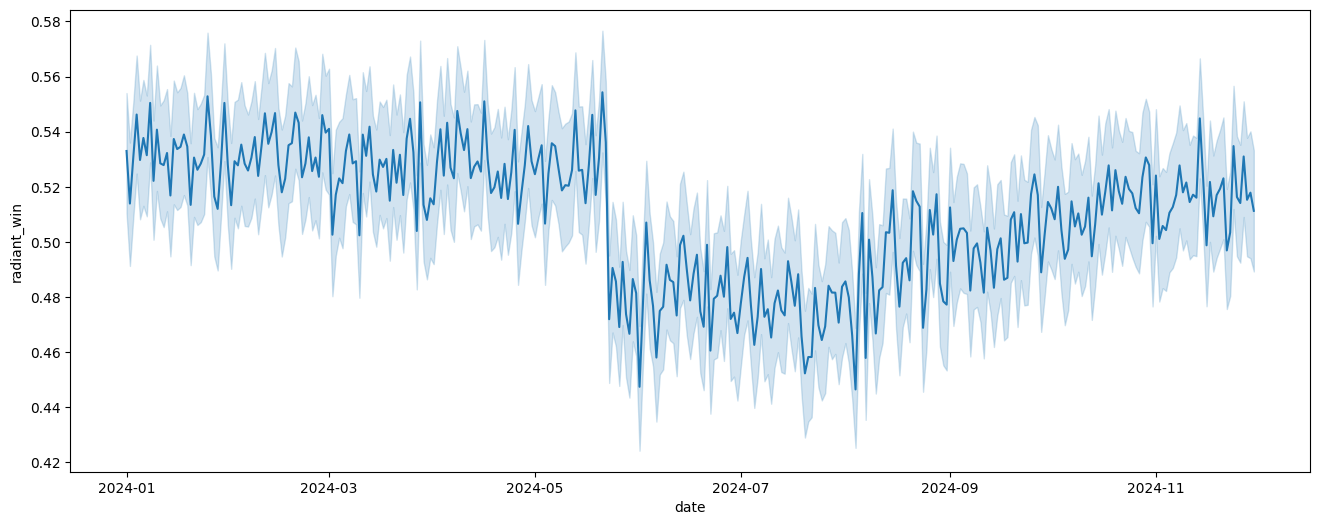

In [8]:
# (´-`）.｡oO( ... YOUR CODE HERE ... )

df_train['date'] = pd.to_datetime(df_train['date'])
df_test['date'] = pd.to_datetime(df_test['date'])

df_train['day'] = df_train['date'].dt.day
df_train['day_of_week'] = df_train['date'].dt.dayofweek

plt.figure(figsize=(16, 6))
sns.lineplot(data=df_train, x='date', y='radiant_win')

print(f'Временные диапазоны на train с {df_train['date'].min().date()} до {df_train['date'].max().date()}')
print(f'Временные диапазоны на test с {df_test['date'].min().date()} до {df_test['date'].max().date()}')

<div style="border-left: 5px solid #c27985; padding: 10px 20px 2px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(255, 116, 140, 0.05);">

**Вопрос:** видите ли вы какой-то паттерн в распределении дат? Можете ли вы объяснить при помощи сети Интернет, что там произошло? \
(Подсказка: соревновательные игры периодически обновляются)

**Ответ:**
По графику видно, что в течение года вероятность победы была неоднозначна, с 2024-01 по 2024-06 видно, что диапазон побед варьировался от ~0,51 до 0,53 в среднем. Но после 2024-06 видно резкое падение в среднем до ~0,48 на протяжение всего периода с 2024-06 по 2024-08 выигрыш находится в этих пределах, но с 2024-08 начинается постепенное увеличение среднего числа до ~0,52 к концу 2024 года. Из-за выхода обновления 7.36 как раз таки в конце мая 2024 года с введением новых механик снизиллся процент побед radiant-ов. С выходом августовских патчей ситуация выправляется и спостепенно приходит к 0,52
</div>

Теперь давайте что-нибудь повыделяем.

<div style="border-left: 5px solid #7298ce; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

Даты сами по себе это всегда очень простые фичи, функционал есть в любой библиотеке. Связь с таргетом может быть, но не обязана. Именно даты проверить легко и быстро, зависимости бывают неожиданными. Впрочем, это не единственная причина, не переключайтесь

</div>

С таймстемпом можно делать не так много, кроме базовых манипуляций:

1. Вытащите лежащую на поверхности информацию, например, день и день недели. Хватит и этих двух
2. Посмотрите сами на список возможных признаков, будь то [pandas](https://pandas.pydata.org/docs/reference/api/pandas.Series.dt.html) или [polars](https://docs.pola.rs/api/python/stable/reference/expressions/temporal.html), и <font color="#d18753">**либо добавьте**</font> 2 признака, которые, как вам кажется, сработают, <font color="#d18753">**либо поясните**</font>, почему это ничего не даст

<div style="border-left: 5px solid #c27985; padding: 10px 20px 2px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(255, 116, 140, 0.05);">

**Вопрос:** необходимо ли кодировать признаки из дат? Если да, то какие и как? Если нет, то почему? </font>

**Ответ:** 
Да, стоит кодировать даты в течение года, ведь в них есть однозначное изменение среднего числа побед (в первую половину 2024 и во вторую он различен), что позволит быть ближе к ответу на +- 2-4 случая из 100, как минимум.

При этом смысла, как показано на графике, в кодировке по дням неделе, как не странно, нет, все дни недели имеют примерно одинаковое распредление с точностью до сотой
</div>

3. Закодируйте новые признаки, согласно вашему ответу

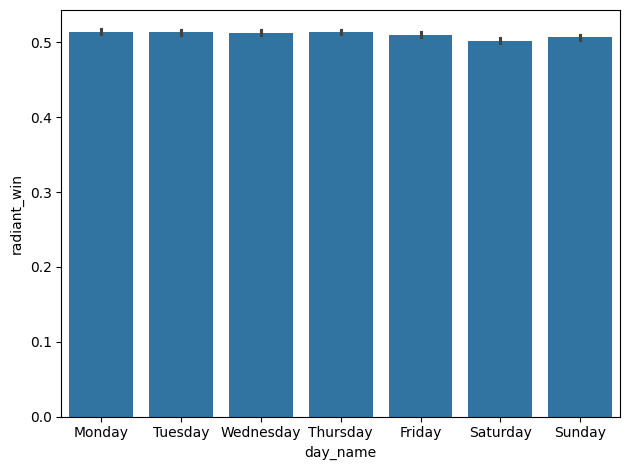

In [9]:
df_train['day_name'] = df_train['date'].dt.day_name()
plt.figure()
days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
sns.barplot(data=df_train, x='day_name', y='radiant_win', order=days)
plt.tight_layout()
plt.show()

In [10]:
# (´-`）.｡oO( ... YOUR CODE HERE ... )

df_train['day_of_year'] = df_train['date'].dt.dayofyear
df_test['day_of_year'] = df_test['date'].dt.dayofyear

df_train['two_night'] = (df_train['day_of_year'] - 1) // 14
df_test['two_night'] = (df_test['day_of_year'] - 1) // 14

encoday = OneHotEncoder(cols=['two_night'], handle_unknown='value', use_cat_names=True)
train_encoded = encoday.fit_transform(df_train[['two_night']])
test_encoded = encoday.transform(df_test[['two_night']])
df_train_final = pd.concat([df_train.drop(columns=['day_of_year', 'two_night']), train_encoded], axis=1)
df_test_final = pd.concat([df_test.drop(columns=['day_of_year', 'two_night']), test_encoded], axis=1)

Кажется, мы что-то забыли... Ах да, надо бы и модель обучить, вот только без валидации это будет как-то не по-моповски, надо озаботиться этим вопросом.

<div style="border-left: 5px solid #7298ce; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

На самом деле временная структура нужна не столь, чтобы вытащить какие-то признаки, сколько, чтобы понять распределение и изменение данных во времени же. Даты играют в этом прямую роль

</div>

<div style="border-left: 5px solid #c27985; padding: 10px 20px 2px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(255, 116, 140, 0.05);">

**Вопрос:** почему здесь будет не лучшим решением брать случайное разбиение на трейн и валидацию?

**Ответ:** При случайном разиении модель не учтет влияние дат - необходимо, чтобы модель четко поняла изменение в первом полугодии, третей четверти и последней четверти года

</div>

Тут выбор у вас решили отобрать, делать мы будем OOT валидацию. Впрочем, какие-то опции ещё остались

<table width="800" border="1" cellpadding="8" cellspacing="0">
  <tr>
    <th width="50%">
      <font color="#d18753">OOT (Out-of-Time)</font>
    </th>
    <th width="50%">
      <font color="#d18753">CV OOT (Cross-Validation Out-of-Time)</font>
    </th>
  </tr>
  <tr>
    <td valign="top">
      Валидация с одной отложенной подвыборкой, <br>
      взятой после трешхолда t. Простая, как палка, <br>
      но если валидация получится грустной — <br>
      аномальной, нетипичной, маленькой, — <br>
      то и метрика ваша тоже будет грустной.
    </td>
    <td valign="top">
      Кросс-валидация с k разбиениями по времени <br>
      с итеративным расширением исходного фолда. <br>
      Оценка метрики сместится куда меньше <br>
      по сравнению с плохим сплитом OOT, <br>
      но это долго, если фолдов много.
    </td>
  </tr>
  <tr>
    <td valign="top">
      <code>sklearn.model_selection.train_test_split</code>
    </td>
    <td valign="top">
      <code>sklearn.model_selection.TimeSeriesSplit</code>
    </td>
  </tr>
</table>



Настройте любой из видов валидации (<font color="#d18753">**трешхолд**</font> `t` или <font color="#d18753">**число фолдов**</font> <code>n_folds</code></font> подберите сами). Они оба должны показывать качество адекватно, хотя второй теоретически должен быть более обоснован. CV-OOT не даст вам бонусов, но кто знает, за какие крохи Джини придётся бороться на соревновании?

In [11]:
# (´-`）.｡oO( ... YOUR CODE HERE ... )
df_train = df_train.sort_values('date')
threshold_date = df_train['date'].quantile(0.8, interpolation='nearest')

X_train = df_train[df_train['date'] <= threshold_date].drop(columns=['radiant_win'])
y_train = df_train[df_train['date'] <= threshold_date]['radiant_win']
X_valid = df_train[df_train['date'] > threshold_date].drop(columns=['radiant_win'])
y_valid = df_train[df_train['date'] > threshold_date]['radiant_win']

И вот теперь мы уже наконец-то будем что-то обучать. Моделей классификации мы знаем как минимум две — SVM и логистическую регрессию, но есть нюанс.

Выборы, выборы..:

<table width="800" border="1" cellpadding="8" cellspacing="0">
  <tr>
    <th width="50%">
      <font color="#d18753">Dedicated model</font>
    </th>
    <th width="50%">
      <font color="#d18753">Gradient Descent</font>
    </th>
  </tr>
  <tr>
    <td valign="top">
      Большой разницы между <code>LogisticRegression</code> и <code>LinearSVC</code> <br>
      из <code>sklearn.linear_model</code> на самом деле нет: <br>
      разделяющие поверхности очень похожи, <br>
      оба хорошо оптимизированы специальными солверами.
    </td>
    <td valign="top">
      Градиентный спуск через <code>sklearn.linear_model.SGDClassifier</code> <br>
      с параметрами <code>loss="log_loss"</code> или <code>loss="hinge"</code> — <br>
      очень соблазнительная альтернатива, но!
    </td>
  </tr>
  <tr>
    <td valign="top">
      <font color="#d18753"><b>+</b></font> Обучать и применять их в разы проще, <br>
      фит–предикт делает брр. <br>
      <font color="#d18753"><b>−</b></font> Они используют сразу всю выборку <br>
      для обучения, а в ходе задания наша выборка <br>
      может вырасти раз так в 1000, немало!
    </td>
    <td valign="top">
      <font color="#d18753"><b>+</b></font> Влезет любой датасет. <br>
      <font color="#d18753"><b>+</b></font> Бóльший контроль над процессом обучения. <br>
      <font color="#d18753"><b>−</b></font> Обучать на больших данных <br>
      (скорее про часть <b>advanced</b>) придётся через <code>partial_fit</code>, неудобно. <br>
      <font color="#d18753"><b>−</b></font> Нужно подбирать больше гиперпараметров.
    </td>
  </tr>
</table>


Выберите <font color="#d18753">**одну из**</font> моделей выше (хотя `LinearRegression` <font color="#d18753">**тоже можно**</font>, если у вас сегодня авантюрное настроение, успех не гарантирован, о рисках узнаете на лекции) **(обращаем внимание, что другие варианты запрещены)**. Обучите по одному экземпляру на группах признаков:

- дат
- регионов
- дат и регионов

Ну и замерьте качество!

<font color="#d18753">**NB**</font>: 

1. Вы сразу можете строить роскошный пайплайн обучения, а не делать по кускам в отдельных блоках, про это есть **advanced** пункт (**6.1**) на 0.5 баллов
2. Если у вас есть GPU, то почему бы его и не [использовать](https://docs.rapids.ai/api/cuml/stable/)? Если гпу у вас нет, у вас теперь точно есть Kaggle, который щедро дарит 30 часов гпу в неделю, пользуйтесь на здоровье, за это есть маленький, но небольшой буст на 0.25 балла (**пункт 6.3**)
3. Наконец, если вы сразу оформите хранилище для результатов запусков ваших моделей, вы снова получите 0.25 балла (**пункт 6.2**)

In [12]:
# (´-`）.｡oO( ... YOUR CODE HERE ... )

def evaluate(X_tr, X_val, y_tr, y_val):
    model = make_pipeline(
        StandardScaler(),
        SGDClassifier(loss='log_loss', penalty='l2',
                      alpha=0.0001, max_iter=1000,
                      random_state=42)
    )
    model.fit(X_tr, y_tr)
    y_pred = model.predict_proba(X_val)[:, 1]
    return gini(y_val, y_pred)

from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import SGDClassifier

X_date_train = train_encoded.loc[df_train['date'] <= threshold_date]
X_date_valid = train_encoded.loc[df_train['date'] > threshold_date]

X_region_train = df_encoded.loc[df_train['date'] <= threshold_date]
X_region_valid = df_encoded.loc[df_train['date'] > threshold_date]

X_both_train = pd.concat([X_date_train, X_region_train], axis=1)
X_both_valid = pd.concat([X_date_valid, X_region_valid], axis=1)

y_train = df_train.loc[df_train['date'] <= threshold_date, 'radiant_win'].astype(int)
y_valid = df_train.loc[df_train['date'] > threshold_date, 'radiant_win'].astype(int)

gini_date = evaluate(X_date_train, X_date_valid, y_train, y_valid)
gini_region = evaluate(X_region_train, X_region_valid, y_train, y_valid)
gini_both = evaluate(X_both_train, X_both_valid, y_train, y_valid)

print(f'Gini (только даты): {gini_date}')
print(f'Gini (только регионы): {gini_region}')
print(f'Gini (даты + регионы): {gini_both}')

Gini (только даты): 0.0007597423408935988
Gini (только регионы): 0.0009559383735333604
Gini (даты + регионы): -0.00016063000070487554


<div style="border-left: 5px solid #c27985; padding: 10px 20px 2px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(255, 116, 140, 0.05);">

**Вопрос:** помогли ли даты? А должны? Хотите ли вы их оставить?

**Ответ:**
В целом даты не дали какого то значительного результата даже без подбора гиперпараметров, смысла в них нет, удалять пока что их не хочится
</div>

#### **Задание 1.4. Числа** (0.75 балла)

Остался неотвеченным лишь один вопрос — а что числовые признаки? С ними всё одновременно и проще, и сложнее.

Найдите, где хранится средний ммр матча — это средний рейтинг игроков, которые в нём участвовали, чем выше, тем лучше.

<div style="border-left: 5px solid #7298ce; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

От ммра напрямую зависит то, как игроки пользуются естественным преимуществом Radiant. Чем игроки сильнее, тем чаще это должно происходить, в теории

</div>

Сделайте (на трейне, валидации и тесте) вот что :
1. Постройте график распределения ммров
2. Сравните, насколько распределения похожи между собой визуально

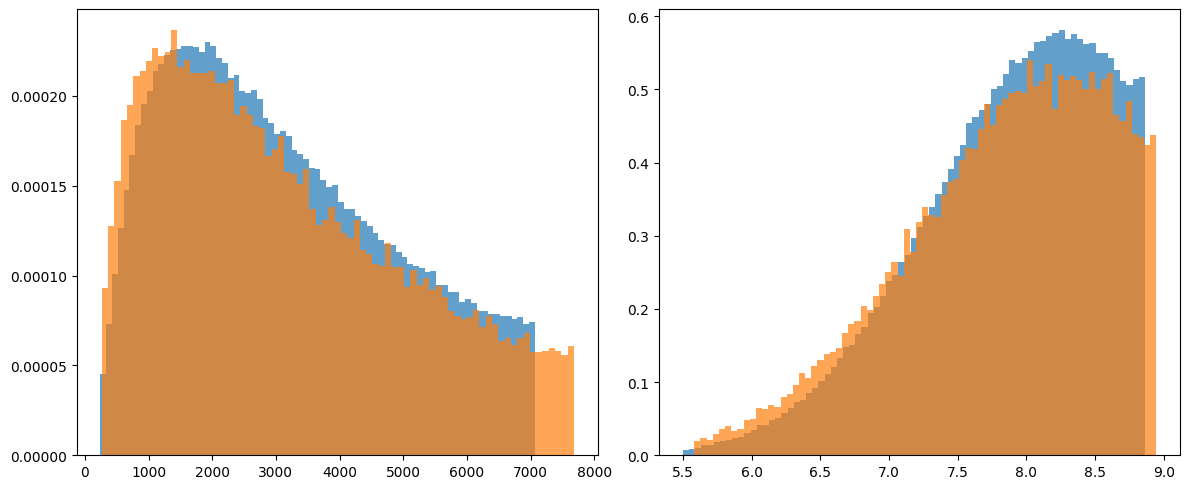

In [13]:
# (´-`）.｡oO( ... YOUR CODE HERE ... )

import numpy as np

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.hist(df_train['avg_mmr'], bins=75, density=True, alpha=0.7, label='train')
plt.hist(df_test['avg_mmr'], bins=75, density=True, alpha=0.7, label='test')

plt.subplot(1,2,2)
mmr_train_log = np.log1p(df_train['avg_mmr'])
mmr_test_log  = np.log1p(df_test['avg_mmr'])
plt.hist(mmr_train_log, bins=75, density=True, alpha=0.7, label='train')
plt.hist(mmr_test_log, bins=75, density=True, alpha=0.7, label='test')
plt.tight_layout()
plt.show()

<div style="border-left: 5px solid #c27985; padding: 10px 20px 2px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(255, 116, 140, 0.05);">

**Вопрос:** как бы вы описали это распределение в целом, похоже ли оно на что-то знакомое вам? 

**Ответ:** Распределение неравномерно с длинным хвостом. При этом применение логарифмировния для выравнивания не дало существнного результата, хвост стал более пологим

</div>

Кто-то где-то говорил, что числовые признаки надо бы стандартизировать, чтобы вышло что-то годное. Этот кто-то прав, но как известно, практика — критерий истины

<div style="border-left: 5px solid #7298ce; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

Но на практике это зависит от данных. Сходимость итеративных алгоритмов улучшается, но может пострадать качество, особенно, если распределение не нормальное, или есть отличие в $\mu$ и $\sigma$ на тесте
 
Однако даже пара пунктов Джини это довольно хороший буст, вы убедитесь, когда приступите к сореве, за них нужно бороться любой ценой, тем более, что это почти бесплатно

</div>

Так или иначе, у нас и распределение то не нормальное, но, к счастью, это решаемо. Сделайте такие преобразования признака ммров $f_{\text{mmr}}$ и нарисуйте их график:

$$f_{\text{mmr}} \mapsto \log( 1+f_{\text{mmr}} ); \qquad f_{\text{mmr}} \mapsto \sqrt{f_{\text{mmr}}}; \qquad f_{\text{mmr}} \mapsto \frac{1}{1+f_{\text{mmr}}}; \qquad f_{\text{mmr}} \mapsto \exp{\log f_{\text{mmr}}};$$

Затем выберите то, что вам нравится больше всего

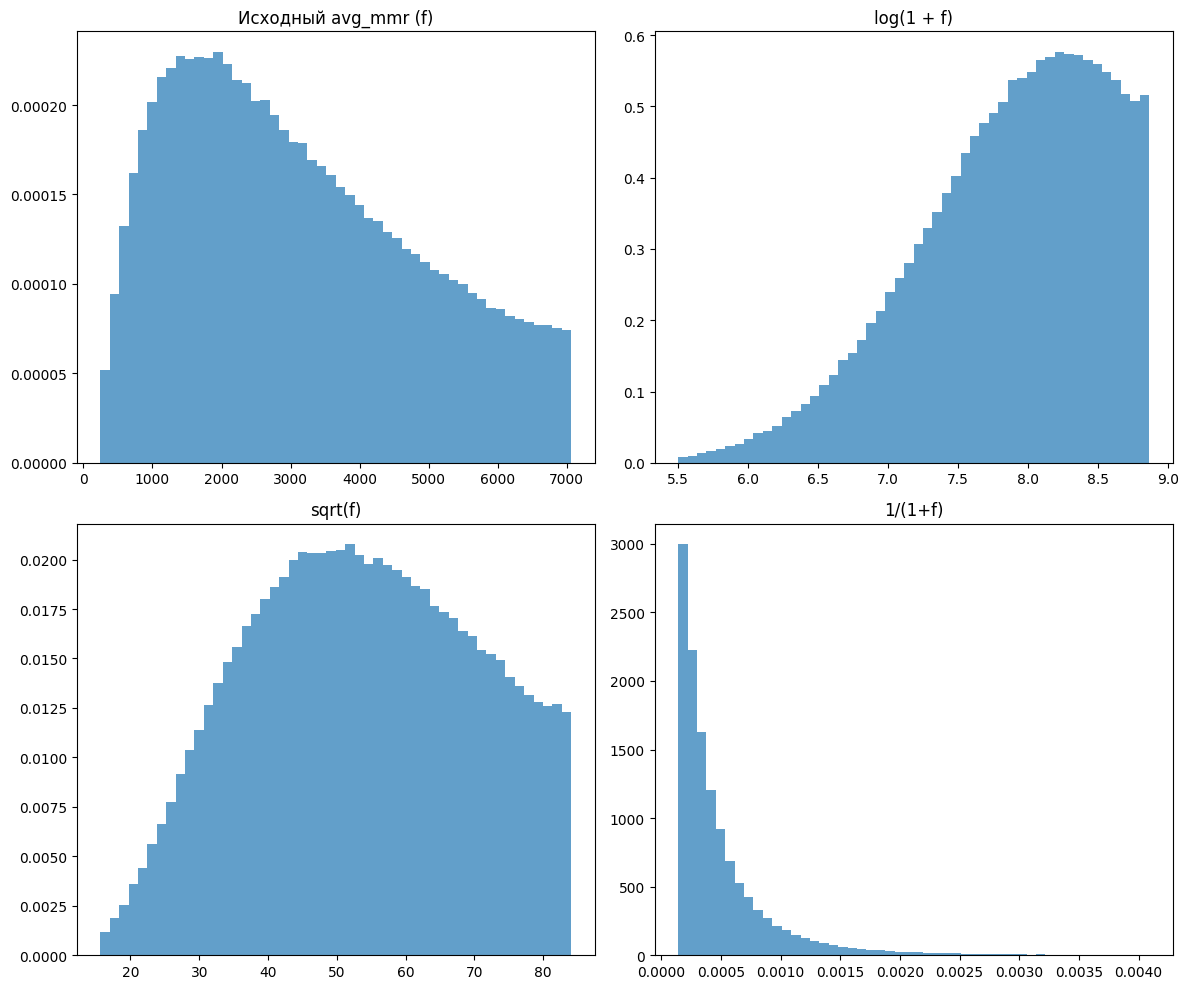

In [14]:
# (´-`）.｡oO( ... YOUR CODE HERE ... )
mmr = df_train['avg_mmr'].copy()

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

axes[0].hist(mmr.dropna(), bins=50, density=True, alpha=0.7)
axes[0].set_title('Исходный avg_mmr (f)')

log1p = np.log1p(mmr)
axes[1].hist(log1p.dropna(), bins=50, density=True, alpha=0.7)
axes[1].set_title('log(1 + f)')

sqrt_f = np.sqrt(mmr)
axes[2].hist(sqrt_f.dropna(), bins=50, density=True, alpha=0.7)
axes[2].set_title('sqrt(f)')

recip = 1 / (1 + mmr)
axes[3].hist(recip.dropna(), bins=50, density=True, alpha=0.7)
axes[3].set_title('1/(1+f)')

plt.tight_layout()
plt.show()

Мы как-то раньше не обращали внимание, но шестое чувство подсказывает, что в ммрах есть пропуски. Выкинуть их не получится, потому что на тесте они тоже есть, поэтому выход один — чем-то заполнять. 

<div style="border-left: 5px solid #7298ce; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

А пропуски у нас есть, потому что не все игры рейтинговые, там информацию по ммру собрать не удастся

В категориальных признаках пропуски не так важны для линрега, их можно закодировать специальной категорией. В числовых проигнорировать их не получится

В любом случае, лучше дополнительно добавить признак-флаг `mmr_missing`, который говорит, что пропуск там на самом деле есть. <font color="#d18753">**Можете**</font> замерить его влияние, если есть желание, может это полная дичь и там Джини 0.9?

</div>

<div style="border-left: 5px solid #c27985; padding: 10px 20px 2px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(255, 116, 140, 0.05);">

**Вопрос:** нормально ли в данном случае заполнить пропуски нулём? А чем тогда, если нет?

**Ответ:** Лучше заполнить средним или медианой,поскольку ноль может исказить данные

</div>

Момент истины. Обучите две новые модели: к оптимальному набору фичей из предыдущего пункта добавьте в одном случае фичу без преобразования, а в другом — после преобразования. Зацените эффект на трейне и на тесте

<div style="border-left: 5px solid #7298ce; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

Помните, что как бы ни было прекрасно и информативно преобразование в вашей голове, ключевое это перформанс на тесте \
В жизни каждого дата-сайентиста бывает такое, что фича, которая ну должна быть клёвой, <i>математически</i>, на практике оказывается той ещё жижей, и такое, увы, тоже нужно отслеживать

</div>

In [15]:
# (´-`）.｡oO( ... YOUR CODE HERE ... )

mask_train = df_train['date'] <= threshold_date
mask_valid = df_train['date'] > threshold_date

train_encoded_part = train_encoded.loc[mask_train].reset_index(drop=True)
train_encoded_part_val = train_encoded.loc[mask_valid].reset_index(drop=True)
df_encoded_part = df_encoded.loc[mask_train].reset_index(drop=True)
df_encoded_part_val = df_encoded.loc[mask_valid].reset_index(drop=True)

X_base_train = pd.concat([train_encoded_part, df_encoded_part], axis=1)
X_base_valid = pd.concat([train_encoded_part_val, df_encoded_part_val], axis=1)

mmr_original = df_train['avg_mmr'].copy()
mmr_median = mmr_original.median()
mmr_filled = mmr_original.fillna(mmr_median)
mmr_missing = mmr_original.isna().astype(int)

mmr_train_filled = mmr_filled.loc[mask_train].reset_index(drop=True)
mmr_valid_filled = mmr_filled.loc[mask_valid].reset_index(drop=True)
mmr_missing_train = mmr_missing.loc[mask_train].reset_index(drop=True)
mmr_missing_valid = mmr_missing.loc[mask_valid].reset_index(drop=True)

mmr_train_log = np.log1p(mmr_train_filled)
mmr_valid_log = np.log1p(mmr_valid_filled)

X_mmr_orig_train = pd.concat([X_base_train, mmr_train_filled, mmr_missing_train], axis=1)
X_mmr_orig_valid = pd.concat([X_base_valid, mmr_valid_filled, mmr_missing_valid], axis=1)
X_mmr_log_train = pd.concat([X_base_train, mmr_train_log, mmr_missing_train], axis=1)
X_mmr_log_valid = pd.concat([X_base_valid, mmr_valid_log, mmr_missing_valid], axis=1)

gini_orig = evaluate(X_mmr_orig_train, X_mmr_orig_valid, y_train, y_valid)
gini_log = evaluate(X_mmr_log_train, X_mmr_log_valid, y_train, y_valid)

print(f'Gini базовые + mmr исходный: {gini_orig}')
print(f'Gini базовые + mmr log1p: {gini_log}')

Gini базовые + mmr исходный: 0.08832331223012146
Gini базовые + mmr log1p: 0.08767255900486859


### **Часть 2. Векторы** (1.5 балла)

В которой студент испытывает вьетнамские флешбеки от дз1, фиксит чужие баги и делает нереально мощную фичу, которую можно полировать до посинения

#### **Задание 2.1. Большая чистка** (0.75 балла)

Пока что мы никак не использовали информацию про героев, а ведь от них напрямую зависит исход матча, их больше 100 штук и все они разные: кто-то сильнее, кто-то слабее, а кто-то красивее :3. Только в данные кто-то нагадил, придётся убирать! Тут придётся ещё разочек освежить `pandas`/`polars`

Датасеты, которые нас интересуют теперь — `player_df.csv` и `Constants.Heroes.csv`. Там есть и данные на трейне, и на тесте, мы их обязательно приджойним, но потом.

<div style="border-left: 5px solid #7298ce; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

Данные, как и стойло, необходимо чистить. Ранее нам везло и в целом каких-то извращений мы не наблюдали, да и тут сходу не увидим. Т.н. *"выбросы"* это, во-первых, тема отдельного холивара, а во-вторых история про доменное несоответствие, матстат такое не найдёт, но на то у нас есть мозг, верно?

Под доменом имеется в виду контекст, в котором создаются ваши данные, и процессы которого ваши данные описывают (в нашем случае — то, как устроена игра и баланс в ней). Тогда выброс — это то, что в контекст не вписывается, даже если ошибки там нет. Про это весь пункт

</div>

Первое, что нужно отсмотреть - главные ключи. Начнём с игроков. Повертите `account_id`, вас должны смутить как минимум два айдишника.

<div style="border-left: 5px solid #7298ce; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

Не все игроки делают свой профиль публичным, их айди в таком случае будет анонимизирован

Небольшая часть данных собрана некорректно, айди таких игроков тоже помечен особенным значением

</div>

In [16]:
# (´-`）.｡oO( ... YOUR CODE HERE ... )
player_df = pd.read_csv("player_df.csv")
player_df

,player_slot,account_id,hero_id,kills,deaths,assists,gold,last_hits,denies,gold_per_min,xp_per_min,hero_damage,tower_damage,match_id
0,130,10111871,5,3.0,8.0,15.0,2971.0,55.0,3.0,291.0,390.0,7431.0,146.0,215380
1,130,43341844,3,3.0,9.0,3.0,1245.0,25.0,3.0,238.0,346.0,4187.0,34.0,185234
2,130,72157343,53,9.0,6.0,20.0,4544.0,226.0,1.0,583.0,704.0,9406.0,2375.0,573078
3,1,4294967295,17,21.0,3.0,15.0,2945.0,209.0,12.0,577.0,641.0,30957.0,1801.0,366576
4,2,54350942,19,9.0,8.0,8.0,413.0,227.0,9.0,471.0,584.0,18215.0,627.0,455795
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7650820,4,4294967295,63,16.0,9.0,10.0,467.0,152.0,5.0,494.0,619.0,24378.0,1700.0,400075
7650821,0,4294967295,95,8.0,11.0,13.0,9.0,183.0,4.0,449.0,544.0,13792.0,4817.0,465077
7650822,3,122912707,36,6.0,3.0,18.0,1078.0,74.0,8.0,334.0,336.0,7769.0,533.0,571444
7650823,0,104518723,87,4.0,11.0,9.0,1017.0,18.0,4.0,219.0,218.0,4087.0,91.0,234954


In [17]:
print(player_df['account_id'].value_counts())
print(player_df.shape)

account_id
 4294967295    2795673
-1               27267
 37619671          801
 84244723          763
 87266522          761
                ...   
 104901614           1
 37533101            1
 55083645            1
 113755406           1
 114328757           1
Name: count, Length: 974931, dtype: int64
(7650825, 14)


<div style="border-left: 5px solid #c27985; padding: 10px 20px 2px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(255, 116, 140, 0.05);">

**Вопрос:** можем ли мы себе позволить выкинуть матчи с какими-либо подозрительными айди без большого ущерба данным?

**Ответ:** в целом выкинуть можно, но это сильно повлияет на данные - большой айди встерчается в 2795673 записях, много записей с -1, при размере 7650825, что очень много

</div>

Следующий логический шаг — одинаковых героев быть в одном матче не должно.  

<div style="border-left: 5px solid #7298ce; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

В кастомных, т.е. не основных режимах игры, это может быть не так, но нас они не интересуют

</div>

Найдите, есть ли игры, в которых это по какой-то причине не так. Если таких матчей не слишком много, избавьтесь от них

In [18]:
# (´-`）.｡oO( ... YOUR CODE HERE ... )
player_df['team'] = player_df['player_slot'].apply(lambda x: 'radiant' if x < 5 else 'dire')
duplicate_heroes = player_df.groupby(['match_id', 'team'])['hero_id'].apply(lambda x: x.duplicated().any())
duplicate_matches = duplicate_heroes[duplicate_heroes].index.get_level_values(0).unique()
player_df = player_df[~player_df['match_id'].isin(duplicate_matches)]

Вы могли заметить героя-импостера под индексом 0. Если вы посмотрите в `Constants.Heroes.csv`, то его там не найдёте, потому что это тоже ошибка.

<div style="border-left: 5px solid #7298ce; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

Скорее всего это те, кто не успел выбрать героя, игра могла просто не начаться

Вряд ли у нас получится заполнить пропуски чем-то адекватным — они зависят от игрока и героя, переменных много. Попробовать можно, но точно не в базовой части

</div>

Финальным аккордом:

- посмотрите, что за игроки играли на герое с `hero_id=0`, и выкиньте такие матчи вместе со всеми пропусками
- найдите игроков, которые в одном матче играли одновременно и за команду сил Тьмы (слоты `{128, ..., 132}`), и за команду сил Света (слоты `{0, ..., 4}`), не являясь подозрительными айди из пункта выше, уберите их
- отфильтруйте `player_df`, оставьте только те матчи, которые есть в наших выборках
- проверьте, что в каждом матче ровно 5 игроков за Свет и ровно 5 за Тьму

Можно в любом порядке, но эти вещи нужно проверить, они поломают следующий пункт

In [19]:
# (´-`）.｡oO( ... YOUR CODE HERE ... )
bad_hero = player_df[player_df['hero_id'] == 0]['match_id'].unique()
player_df = player_df[~player_df['match_id'].isin(bad_hero)]
ids = [4294967295, -1]
df_check = player_df[~player_df['account_id'].isin(ids)].copy()
conflict = df_check.groupby(['match_id', 'account_id'])['team'].nunique()
conflict_matches = conflict[conflict > 1].index.get_level_values(0).unique()
player_df = player_df[~player_df['match_id'].isin(conflict_matches)]

all_match_ids = set(df_train['match_id']).union(set(df_test['match_id']))
player_df = player_df[player_df['match_id'].isin(all_match_ids)]

Если вас всё же одолевает паранойя, то ~~я вас понимаю~~ будьте уверены, что если проблемы в `player_df` и остались, на модель они повлияют минимально. Ну а идеала не бывает нигде

#### **Задание 2.2. Энкодер героев** (0.75 балла)

А зачем мы вообще этим занимаемся? Вопрос хороший. План был в том, чтобы закодировать комбинации героев, которые участвуют в матче. Это чуть более сложный признак, чем обычный трансформ, тут придется поколдовать.

<div style="border-left: 5px solid #7298ce; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

Идея в том, что какие-то комбинации героев эффективнее других. Если понять, что в матче за персонажи, можно сразу же прикинуть шансы на победу одной из сторон

</div>

Ваша задача - закодировать каждый матч вектором вида:

| match_id | hero_1 | hero_2 | hero_3 | ... | hero_n |
| --- | --- | --- | --- | --- | --- |
| 228 | 1 | 0 | -1 | ... | 0 |

<div style="border-left: 5px solid #7298ce; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

Потом <font color="#d18753">**можно**</font> бахнуть One-Hot и разбить героев на две команды, если не боитесь переобучения. Вещь необязательная

</div>

Потребуются таблицы `player_df.csv` и `matches_df_*.csv`. Для удобства может пригодиться `Constants.Heroes.csv` (индексы оттуда и в `player_df` верные, по ним можно джойнить, но они идут не по порядку, не смотрите на пандасовский айди).

Хочется видеть либо функцию, либо в идеале класс, который вертит фичами вот так:

Каждый элемент в векторе матча `(hero_1, ..., hero_n)` принимает значение 1, если герой был в команде сил Света (слоты `{0, ..., 4}`), и -1, если в команде сил Тьмы (слоты `{128, ..., 132}`). 

<div style="border-left: 5px solid #7298ce; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

Класс нужен, поскольку при неаккуратной реализации есть риск не влезть в память при трансформе целого датасета. Главное, чтобы была функция, а там можно применять её на батч. 

Либо же <font color="#d18753">**можете**</font> преисполниться спарс матрицами, которые экономно (не) хранят миллионы нулей. Вещь несложная и полезная

</div>

Реализуйте то, что написано

In [20]:
from scipy.sparse import csr_matrix

class HeroesEncoder:

    def __init__(self):
        self.hero_ids_ = None
        self.hero_to_idx_ = None

    def fit(self, X, y=None):
        self.hero_ids_ = np.sort(X['hero_id'].unique())
        self.hero_to_idx_ = {hero: i for i, hero in enumerate(self.hero_ids_)}
        return self

    def transform(self, X):
        grouped = X.groupby('match_id')
        match_ids = []
        rows, cols, data = [], [], []

        for row_idx, (match_id, group) in enumerate(grouped):
            match_ids.append(match_id)
            for _, row in group.iterrows():
                hero_idx = self.hero_to_idx_[row['hero_id']]
                sign = 1 if row['player_slot'] < 5 else -1
                rows.append(row_idx)
                cols.append(hero_idx)
                data.append(sign)

        n_matches = len(match_ids)
        n_heroes = len(self.hero_ids_)
        matrix = csr_matrix((data, (rows, cols)), shape=(n_matches, n_heroes))
        return match_ids, matrix

Осталось лишь самое сладкое — проверить фичу в деле. Обучите две модели: одну со всеми фичами, что мы накрутили, и одну только с фичами героев, покажите качество

In [21]:
from scipy.sparse import hstack, csr_matrix

mask_train = df_train['date'] <= df_train['date'].quantile(0.8, interpolation='nearest')
mask_valid = df_train['date'] > df_train['date'].quantile(0.8, interpolation='nearest')

match_ids_train = df_train.loc[mask_train, 'match_id'].tolist()
match_ids_valid = df_train.loc[mask_valid, 'match_id'].tolist()

hero_encoder = HeroesEncoder()
hero_encoder.fit(player_df)
hero_match_ids, hero_matrix_sparse = hero_encoder.transform(player_df)

existing_match_ids = set(hero_match_ids)

filtered_train_mids = [mid for mid in match_ids_train if mid in existing_match_ids]
filtered_valid_mids = [mid for mid in match_ids_valid if mid in existing_match_ids]

y_train_series = df_train.loc[mask_train].set_index('match_id')['radiant_win'].astype(int)
y_valid_series = df_train.loc[mask_valid].set_index('match_id')['radiant_win'].astype(int)

X_base_train_indexed = X_base_train.copy()
X_base_train_indexed.index = df_train.loc[mask_train, 'match_id'].values
X_base_valid_indexed = X_base_valid.copy()
X_base_valid_indexed.index = df_train.loc[mask_valid, 'match_id'].values

y_train_filtered = y_train_series.loc[filtered_train_mids]
y_valid_filtered = y_valid_series.loc[filtered_valid_mids]

X_base_train_filtered = X_base_train_indexed.loc[filtered_train_mids]
X_base_valid_filtered = X_base_valid_indexed.loc[filtered_valid_mids]

match_id_to_index = {mid: i for i, mid in enumerate(hero_match_ids)}
train_indices = [match_id_to_index[mid] for mid in filtered_train_mids]
valid_indices = [match_id_to_index[mid] for mid in filtered_valid_mids]

hero_train = hero_matrix_sparse[train_indices]
hero_valid = hero_matrix_sparse[valid_indices]

X_base_train_sparse = csr_matrix(X_base_train_filtered.values)
X_base_valid_sparse = csr_matrix(X_base_valid_filtered.values)

X_train_all = hstack([hero_train, X_base_train_sparse])
X_valid_all = hstack([hero_valid, X_base_valid_sparse])

model_all = SGDClassifier(loss='log_loss', alpha=0.0001, max_iter=1000, random_state=42)
model_all.fit(X_train_all, y_train_filtered)
y_pred_all = model_all.predict_proba(X_valid_all)[:, 1]
gini_all = gini(y_valid_filtered, y_pred_all)

model_hero = SGDClassifier(loss='log_loss', alpha=0.0001, max_iter=1000, random_state=42)
model_hero.fit(hero_train, y_train_filtered)
y_pred_hero = model_hero.predict_proba(hero_valid)[:, 1]
gini_hero = gini(y_valid_filtered, y_pred_hero)

print(f'Gini все признаки: {gini_all}')
print(f'Gini только герои : {gini_hero}')

Gini все признаки: 0.2641549776625831
Gini только герои : 0.2649991475661895


Итого у вас должно получиться что-то на уровне $\text{Gini} = 0.25$ на тесте, а может даже выше

<div style="border-left: 5px solid #7298ce; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

Вы могли заметить, что прирост получится не таким значительным, как можно было ожидать, хотя признак сильный. Чем больше добавлять хороших признаков, тем лучше и лучше они объясняет данные.

Даже сложный и хороший по отдельности признак в комбинации с другими будет давать всё меньшее качество. Отчасти это объясняется мультиколлинеарностью, отчасти природой данных, некоторые из них просто слишком сложны

</div>

### **Часть 3. Оптимизация (1.25 балла)**

В которой студент изучает, как оптимизировать модель **по-взрослому**

#### **Задание 3.1. Optuna для самых маленьких** (0.75 балла)

Не стоит забывать, что у любой модели есть <font color="#d18753">**гиперпараметры**</font>. Конечно, львиная доля качества будет идти от фичей, но списывать их со счетов не стоит. В конце концов, бывает, что с безнадёжным на первый взгляд набором признаков, оптимизированная модель покажет лучшее качество, чем базовая модель на топовых фичах, вот и посмотрим.
<a id="section"></a>

Для эффективного подбора гиперпараметров существует несколько решений, основанных на байесовской оптимизации. Одно из наиболее удобных — [optuna](https://optuna.org/), которая делает перебор гиперпараметров таким же лёгким и увлекательным занятием, как составление домашек по МО.

<div style="border-left: 5px solid #7298ce; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

Идея — смоделировать, какой набор гиперпараметров даст лучшее качество там, где перспективнее, на основе истории их подбора (подробнее на МО2)

</div>

Напишите функцию оптимизации для вашего классификатора. Можете воспользоваться шаблоном ниже, но он довольно куцый, курите документацию. Раз уж инструмент новый, начнём с чего-то простого. Подберите вот такие гиперпараметры (посмотрите на них, прежде, чем тюнить, у них разные диапазоны и разный же смысл (логарифмическая шкала — наш лучший друг, возможно даже лучше настоящих)):

1) Численный — `alpha` у `SGDClassifier` или параметр регуляризации `C` у всех остальных.
2) Категориальный — `solver` у `LogisticRegression`, `loss` у всех остальных
3) Число итераций — `max_iter`. Это не совсем гиперпараметр, но поверьте, обучать модель 100 лет вы не хотите, к тому же это вид неявной регуляризации

<div style="border-left: 5px solid #7298ce; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

Раз уж все алгоритмы у нас итерационные, от того, как и по какой функции оптимизироваться, довольно важно

Способов применять оптуну вновь два. \
<font color="#d18753">**Первое**</font> — тестить после каждой фичи, это точнее, но можем переобучиться. <font color="#d18753"> \
**Второе**</font> — подобрать параметры один раз, это проще, но зато быстро. У нас модель простая и перебирать там можно мало чего, пока что, во второй части параметров станет больше. \
Выбор, как всегда, в ваших руках.

</div>

In [22]:
!pip3 install optuna
!pip3 install plotly nbformat --upgrade


[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip

[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip


In [23]:
import optuna

def objective(trial):
    alpha = trial.suggest_float('alpha', 1e-6, 1e-1, log=True)
    loss = trial.suggest_categorical('loss', ['log_loss', 'hinge'])
    max_iter = trial.suggest_int('max_iter', 500, 3000, step=100)
    model = SGDClassifier(
        loss=loss,
        alpha=alpha,
        max_iter=max_iter,
        random_state=42
    )
    model.fit(X_train_all, y_train_filtered)
    if loss == 'log_loss':
        y_pred = model.predict_proba(X_valid_all)[:, 1]
    else:
        y_pred = model.decision_function(X_valid_all)
    gini_val = gini(y_valid_filtered, y_pred)
    return gini_val

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=30, show_progress_bar=True)
print("Лучшее значение Gini:", study.best_value)
print("Лучшие гиперпараметры:", study.best_params)

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[I 2026-03-13 23:31:23,887] A new study created in memory with name: no-name-4d826ae7-be8a-4ce9-8795-bac9040ab900
Best trial: 0. Best value: 0.269405:   3%|▎         | 1/30 [00:00<00:21,  1.35it/s]

[I 2026-03-13 23:31:24,636] Trial 0 finished with value: 0.26940548008715504 and parameters: {'alpha': 0.0007185551795968044, 'loss': 'log_loss', 'max_iter': 1900}. Best is trial 0 with value: 0.26940548008715504.


Best trial: 0. Best value: 0.269405:   7%|▋         | 2/30 [00:04<01:12,  2.58s/it]

[I 2026-03-13 23:31:28,509] Trial 1 finished with value: 0.24089001383949538 and parameters: {'alpha': 3.165681242901453e-06, 'loss': 'hinge', 'max_iter': 500}. Best is trial 0 with value: 0.26940548008715504.


Best trial: 0. Best value: 0.269405:  10%|█         | 3/30 [00:05<00:51,  1.91s/it]

...

[I 2026-03-13 23:31:51,712] Trial 27 finished with value: 0.2633224154687057 and parameters: {'alpha': 0.024479106196849454, 'loss': 'log_loss', 'max_iter': 1500}. Best is trial 15 with value: 0.2698151522213137.


Best trial: 15. Best value: 0.269815:  97%|█████████▋| 29/30 [00:28<00:00,  1.48it/s]

[I 2026-03-13 23:31:52,435] Trial 28 finished with value: 0.26919536314129333 and parameters: {'alpha': 0.0005947523466007333, 'loss': 'log_loss', 'max_iter': 2300}. Best is trial 15 with value: 0.2698151522213137.


Best trial: 15. Best value: 0.269815: 100%|██████████| 30/30 [00:29<00:00,  1.03it/s]

[I 2026-03-13 23:31:53,111] Trial 29 finished with value: 0.26931415243972934 and parameters: {'alpha': 0.0006592840223811706, 'loss': 'log_loss', 'max_iter': 2000}. Best is trial 15 with value: 0.2698151522213137.
Лучшее значение Gini: 0.2698151522213137
Лучшие гиперпараметры: {'alpha': 0.001710346661287368, 'loss': 'log_loss', 'max_iter': 2100}


#### **Задание 3.2. Немножко про интерпретацию** (0.25 балла)

В оптуне лежит целая россыпь визуализаций, как же их не пощупать? Чтобы окончательно убедить вас в ценности и важности регуляризации, выведите график важности гиперпараметров. Оценим, что реально важно, а что пшик

In [24]:
# (´-`）.｡oO( ... YOUR CODE HERE ... )
import optuna.visualization as vis

fig = vis.plot_param_importances(study)
fig.show()

<div style="border-left: 5px solid #c27985; padding: 10px 20px 2px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(255, 116, 140, 0.05);">

**Вопрос:** что вы видите и как вы прокомментируете, какие параметры важнее всего?

**Ответ:** $\alpha$ обладает наибольшим весом, поскольку от нее зависит реугляризация и влияние на обобщающую способность модели. Выбор loss, как получается, не влияет на качество предсказания

</div>

#### **Задание 3.3. Заключение** (0.25 балла)

Фуух, много конечно, ну да так уж вышло, что теперь делать, данные это всегда геморрой. Напоследок:

1. Зафиксируйте оптимальный набор гиперпараметров. 
2. Сохраните либо модель, либо pipeline для будущего себя в части advanced. 
3. Сделайте тестовый submission на [Kaggle](https://www.kaggle.com/t/6fd940fbeb1746a78031e5d0277f6105), если ещё не.

In [26]:
# (´-`）.｡oO( ... YOUR CODE HERE ... )

from scipy.sparse import vstack, hstack, csr_matrix, lil_matrix

X_final_train = vstack([X_train_all, X_valid_all])
y_final_train = pd.concat([y_train_filtered, y_valid_filtered])

best_params = study.best_params
final_model = SGDClassifier(**best_params, random_state=42)
final_model.fit(X_final_train, y_final_train)

test_regions_encoded = encoder.transform(df_test[['region']])

df_test['date'] = pd.to_datetime(df_test['date'])
df_test['day_of_year'] = df_test['date'].dt.dayofyear
df_test['two_night'] = (df_test['day_of_year'] - 1) // 14
test_dates_encoded = encoday.transform(df_test[['two_night']])

mmr_median = df_train['avg_mmr'].median()
test_mmr_filled = df_test['avg_mmr'].fillna(mmr_median)
test_mmr_missing = df_test['avg_mmr'].isna().astype(int)
test_mmr_log = np.log1p(test_mmr_filled)

X_base_test = pd.concat([
    test_regions_encoded.reset_index(drop=True),
    test_dates_encoded.reset_index(drop=True),
    pd.Series(test_mmr_log, name='mmr_log'),
    pd.Series(test_mmr_missing, name='mmr_missing')
], axis=1)

train_base_columns = X_base_train_filtered.columns.tolist()
X_base_test = X_base_test[train_base_columns]

player_df_test = player_df[player_df['match_id'].isin(df_test['match_id'])]
hero_test_match_ids, hero_test_sparse = hero_encoder.transform(player_df_test)
hero_test_index = {mid: i for i, mid in enumerate(hero_test_match_ids)}

n_heroes = hero_train.shape[1]
n_test = len(df_test)

hero_test_full = lil_matrix((n_test, n_heroes), dtype=int)

for i, mid in enumerate(df_test['match_id']):
    if mid in hero_test_index:
        row = hero_test_sparse[hero_test_index[mid]].toarray().flatten()
        hero_test_full[i] = row

hero_test_full = hero_test_full.tocsr()

X_base_test_sparse = csr_matrix(X_base_test.values)
X_test_all = hstack([hero_test_full, X_base_test_sparse])

y_test_pred = final_model.predict_proba(X_test_all)[:, 1]

submission = pd.DataFrame({
    'ID': df_test['match_id'].values,
    'Value': y_test_pred
})
submission.to_csv('submission.csv', index=False)